In [ ]:
import sys 
sys.path.append("/home/feity/cryoem/")
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import utils
import torch
import importlib 
import modules
import data
import scanpy as sc 
import postprocess 
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
import numpy as np

In [3]:
a = pd.read_csv("/home/feity/cryoem/temp/hsp60/24092001_ori/labels.csv")
a.append(a)

AttributeError: 'DataFrame' object has no attribute 'append'

In [2]:
# load model
model = utils.loadModel("/data/transformer_project/transforemer_model/train_data/training/results/conditional_detr_mrc_clean/fold2_ribo", "stage2/last.ckpt")
# model = utils.loadModel("/data/transformer_project/transforemer_model/train_data/training/results/conditional_detr_mrc_final/fold1", "stage3/epoch=6-total_validate_loss=1.1811.ckpt")
# model = utils.loadModel("/data/transformer_project/transforemer_model/train_data/training/results/conditional_detr_mrc_final/fold1_stage3_new", "epoch=4-total_validate_loss=0.9694.ckpt")
# model = utils.loadModel("/data/transformer_project/transforemer_model/train_data/training/results/conditional_mrc_hsp60/test_stage3", "epoch=4-total_validate_loss=0.0284.ckpt")
model = model.eval() 

Some weights of ConditionalDetrForObjectDetection were not initialized from the model checkpoint at microsoft/conditional-detr-resnet-50 and are newly initialized because the shapes did not match:
- class_labels_classifier.bias: found shape torch.Size([91]) in the checkpoint and torch.Size([1]) in the model instantiated
- class_labels_classifier.weight: found shape torch.Size([91, 256]) in the checkpoint and torch.Size([1, 256]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


model at stage  stage 1
model with output classes 2
model receiving class weights tensor([1.0000, 0.6000])
using consistency regularization coef 0.5


/data/biosoftware/miniconda3/miniconda3/envs/pytorch/lib/python3.12/site-packages/torch/nn/modules/transformer.py:307: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")
/home/feity/cryoem/utils.py:1091: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be all

incompatible parameters ['model.class_labels_classifier.weight', 'model.class_labels_classifier.bias', 'additional_input_layer.layer1.weight', 'additional_input_layer.layer1.bias', 'additional_input_layer.layer2.weight', 'additional_input_layer.layer2.bias', 'gnn.conv1.lin_l.weight', 'gnn.conv1.lin_l.bias', 'gnn.conv1.lin_r.weight', 'gnn.conv2.lin_l.weight', 'gnn.conv2.lin_l.bias', 'gnn.conv2.lin_r.weight', 'gnn.conv3.lin_l.weight', 'gnn.conv3.lin_l.bias', 'gnn.conv3.lin_r.weight', 'gnn.cls_head.0.weight', 'gnn.cls_head.0.bias', 'gnn.cls_head.2.weight', 'gnn.cls_head.2.bias', 'gnn.box_head.0.weight', 'gnn.box_head.0.bias', 'gnn.box_head.2.weight', 'gnn.box_head.2.bias', 'gnn.edge_head.0.weight', 'gnn.edge_head.0.bias', 'gnn.edge_head.2.weight', 'gnn.edge_head.2.bias', 'gnn.edge_head.4.weight', 'cri.weight']
finish loading parameters


/home/feity/cryoem/utils.py:1129: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(os.path.join(path, checkpoint), map_location="cpu")["state_dict"]


incompatible parameters []
finish loading parameters


In [4]:
# build test dataset and generate dataframe
# Note: make sure the gap is consistent with the model training
dataset = data.MrcDataset(
    # "/data/transformer_project/transforemer_model/test_data/dxd20240920_hsp60/24092018.pkl",
    # "/data/transformer_project/transforemer_model/test_data/dxd20240920_hsp60/24092002.pkl", 
    # "/data/transformer_project/transforemer_model/train_data/training/newdata/sllt0039_interpolate.pkl",
    "/data/transformer_project/transforemer_model/train_data/training/newdata/24092026_ribo.pkl",
    norm="hist",
    reshape=800,
    map_class={"ribosome":0 },
    gap=1,
    length_for_average=3,
    transform=data.getConstantTransform(),
    add_classname=True,
    filtermin=0
)
model = model.cpu()
df, graphs = postprocess.generatedf(model, dataset, gap = 1, columns=["ribo", "None"], filter_prob=0.2)
# df, graphs = postprocess.generatedf(model, dataset, gap = 5, columns=["ribo", "mitochondria", "nucleus", "endoplasmic_reticulum_or_Golgi", "None"])

reading dataset: /data/transformer_project/transforemer_model/train_data/training/newdata/24092026_ribo.pkl
dataset map classes:  {'ribosome': 0}
dataset length: 431


100%|██████████| 431/431 [03:37<00:00,  1.99it/s]


finish dataset
build graph
prepare df


In [10]:
import postprocess
importlib.reload(postprocess)

df["unlabeled"] = True 
df["label"] = "" 
df["label_id"] = -1
df["largest"].value_counts()

# sllt0039
# important parameters for postprocessing
# min_samples and dis_penalty_cutoff
# if the size of the object changes throughout the tomogram, increase eps 
# if the object is small, add a little bit to enlarge the bounding box 

# params= {
#     "endoplasmic_reticulum_or_Golgi":{"min_prob":0.5, "nms":0.6, "dbscan_prams":{"min_samples": 20, "eps": 0.5, "dis_penalty_coef": 1.0*(1/500), "dis_penalty_cutoff": 20}}, 
#     "mitochondria":{"min_prob":0.4, "nms":0.2, "dbscan_prams":{"min_samples": 25, "eps": 0.5, "dis_penalty_coef": 1.0*(1/500), "dis_penalty_cutoff": 20}}, 
#     "nucleus":{"min_prob":0.4, "nms":0.2, "dbscan_prams":{"min_samples": 25, "eps": 0.5, "dis_penalty_coef": 1.0*(1/500), "dis_penalty_cutoff": 20}}, 
#     "ribo":{"min_prob":0.4, "nms":0.2, "max_area":0.05*0.05, "dbscan_prams":{"min_samples": 6, "eps": 0.5, "dis_penalty_coef": 2.0*(1/500), "dis_penalty_cutoff": 5}}, 
#     "hsp60":{"min_prob":0.6, "nms":0.2, "max_area":0.03*0.03, "dbscan_prams":{"min_samples": 4, "eps": 0.5, "dis_penalty_coef": 2.0*(1/500), "dis_penalty_cutoff": 3, "enlarge": 0.03}}, 
# }

# mark_and_filter = {
#     "nucleus":{"max_cnt":1, "remove_iou": 0.4, "min_samples":20}, 
#     "mitochondria":{"max_cnt":10, "remove_iou": 0.6, "min_samples":20}, 
#     "endoplasmic_reticulum_or_Golgi":{"max_cnt":20, "remove_iou": 0.8, "min_samples":20}, 
#     "ribo":{"max_cnt":80000, "remove_iou": 0.5, "min_samples":12, "min_length":16, "extend":0, "max_samples":30}, 
#     "hsp60":{"max_cnt":5000, "remove_iou": 0.5, "min_samples":5, "min_length":10, "extend":0, "max_samples":30},
# }

# params= {
#     "endoplasmic_reticulum_or_Golgi":{"min_prob":0.5, "nms":0.6, "dbscan_prams":{"min_samples": 20, "eps": 0.5, "dis_penalty_coef": 1.0*(1/500), "dis_penalty_cutoff": 20}}, 
#     "mitochondria":{"min_prob":0.4, "nms":0.2, "dbscan_prams":{"min_samples": 25, "eps": 0.5, "dis_penalty_coef": 1.0*(1/500), "dis_penalty_cutoff": 20}}, 
#     "nucleus":{"min_prob":0.4, "nms":0.2, "dbscan_prams":{"min_samples": 25, "eps": 0.5, "dis_penalty_coef": 1.0*(1/500), "dis_penalty_cutoff": 20}}, 
#     "ribo":{"min_prob":0.4, "nms":0.2, "dbscan_prams":{"min_samples": 6, "eps": 0.5, "dis_penalty_coef": 2.0*(1/500), "dis_penalty_cutoff": 5}}, 
#     "hsp60":{"min_prob":0.6, "nms":0.2, "max_area":0.03*0.03, "dbscan_prams":{"min_samples": 4, "eps": 0.5, "dis_penalty_coef": 2.0*(1/500), "dis_penalty_cutoff": 3, "enlarge": 0.03}}, 
# }

# mark_and_filter = {
#     "nucleus":{"max_cnt":1, "remove_iou": 0.4, "min_samples":20}, 
#     "mitochondria":{"max_cnt":10, "remove_iou": 0.6, "min_samples":20}, 
#     "endoplasmic_reticulum_or_Golgi":{"max_cnt":20, "remove_iou": 0.8, "min_samples":20}, 
#     "ribo":{"max_cnt":80000, "remove_iou": 0.5, "min_samples":12, "min_length":16, "extend":0, "max_samples":30}, 
#     "hsp60":{"max_cnt":5000, "remove_iou": 0.5, "min_samples":5, "min_length":10, "extend":0, "max_samples":30},
# }

params = {
    "endoplasmic_reticulum_or_Golgi": {
        "min_prob": 0.5,
        "nms": 0.6,
        "dbscan_prams": {
            "min_samples": 20,
            "eps": 0.5,
            "dis_penalty_coef": 1.0 * (1 / 500),
            "dis_penalty_cutoff": 20,
        },
    },
    "mitochondria": {
        "min_prob": 0.4,
        "nms": 0.2,
        "dbscan_prams": {
            "min_samples": 25,
            "eps": 0.5,
            "dis_penalty_coef": 1.0 * (1 / 500),
            "dis_penalty_cutoff": 20,
        },
    },
    "nucleus": {
        "min_prob": 0.4,
        "nms": 0.2,
        "dbscan_prams": {
            "min_samples": 25,
            "eps": 0.5,
            "dis_penalty_coef": 1.0 * (1 / 500),
            "dis_penalty_cutoff": 20,
        },
    },
    "ribo": {
        "min_prob": 0.4,
        "nms": 0.2,
        "dbscan_prams": {
            "min_samples": 6,
            "eps": 0.5,
            "dis_penalty_coef": 2.0 * (1 / 500),
            "dis_penalty_cutoff": 5,
        },
    },
    "hsp60": {
        "min_prob": 0.5,
        "nms": 0.2,
        "max_area": 0.03 * 0.03,
        "dbscan_prams": {
            "min_samples": 4,
            "eps": 0.5,
            "dis_penalty_coef": 2.0 * (1 / 500),
            "dis_penalty_cutoff": 3,
            "enlarge": 0.03,
        },
    },
}

mark_and_filter = {
    "nucleus": {"max_cnt": 1, "remove_iou": 0.4, "min_samples": 20},
    "mitochondria": {"max_cnt": 10, "remove_iou": 0.6, "min_samples": 20},
    "endoplasmic_reticulum_or_Golgi": {
        "max_cnt": 20,
        "remove_iou": 0.8,
        "min_samples": 20,
    },
    "ribo": {
        "max_cnt": 80000,
        "remove_iou": 0.5,
        "min_samples": 12,
        "min_length": 16,
        "extend": 0,
        "max_samples": 30,
    },
    "hsp60": {
        "max_cnt": 5000,
        "remove_iou": 0.5,
        "min_samples": 5,
        "min_length": 10,
        "extend": 0,
        "max_samples": 30,
    },
}


for i in ["ribo"]:
    subdf = postprocess.processClass(df, i, **params[i])
    postprocess.markFilter(df, i, subdf, **mark_and_filter[i])



6 0.5 0.004 5
number of instances in class  1533


24092002


/data/biosoftware/miniconda3/miniconda3/envs/pytorch/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


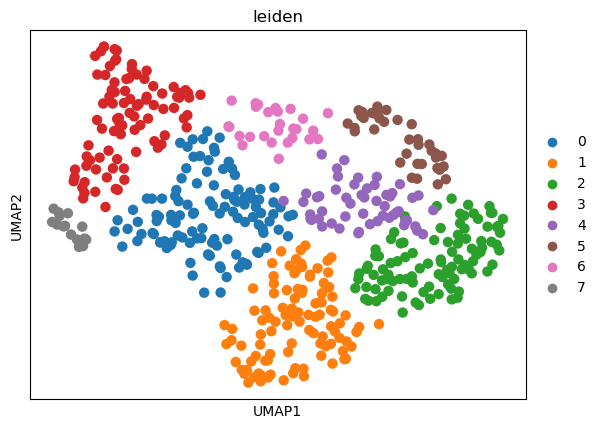

24092013


/data/biosoftware/miniconda3/miniconda3/envs/pytorch/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


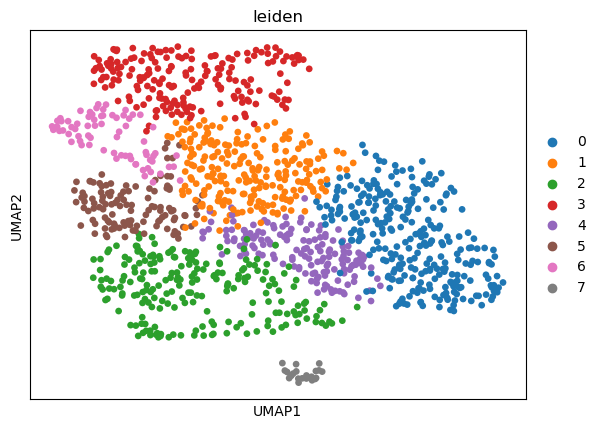

24092016


/data/biosoftware/miniconda3/miniconda3/envs/pytorch/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


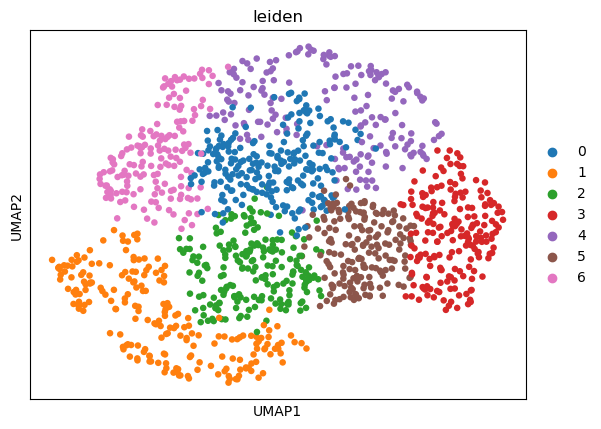

24092020


/data/biosoftware/miniconda3/miniconda3/envs/pytorch/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


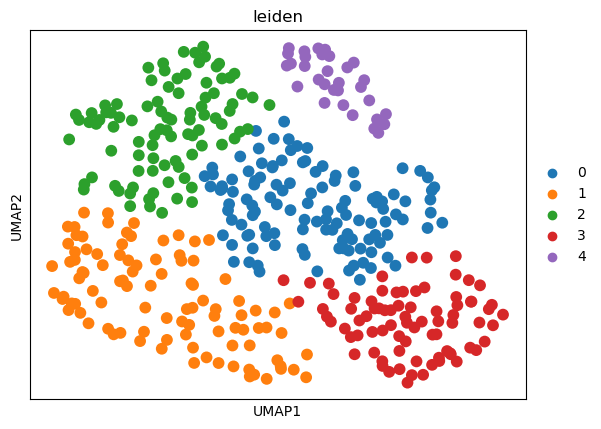

24092024


/data/biosoftware/miniconda3/miniconda3/envs/pytorch/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


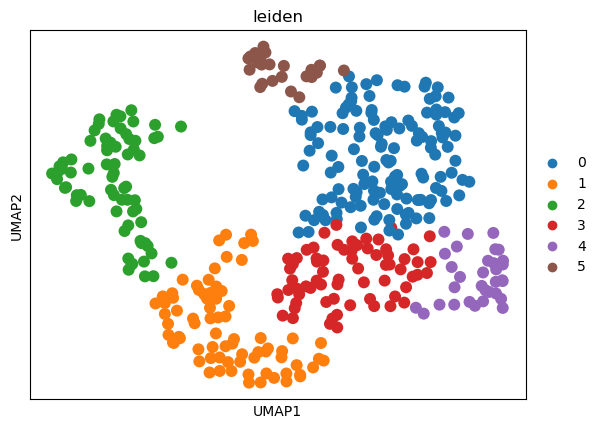

24092026


/data/biosoftware/miniconda3/miniconda3/envs/pytorch/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


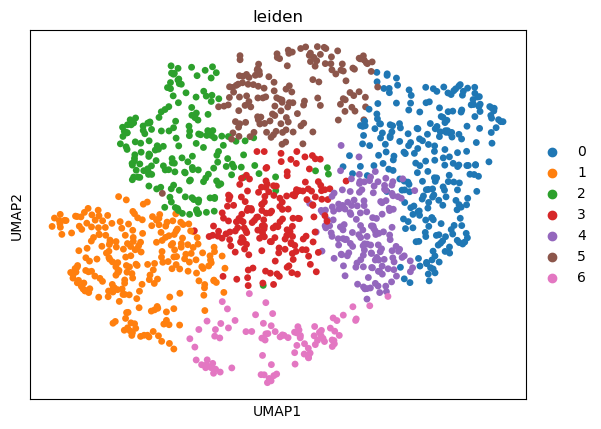

24092030


/data/biosoftware/miniconda3/miniconda3/envs/pytorch/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


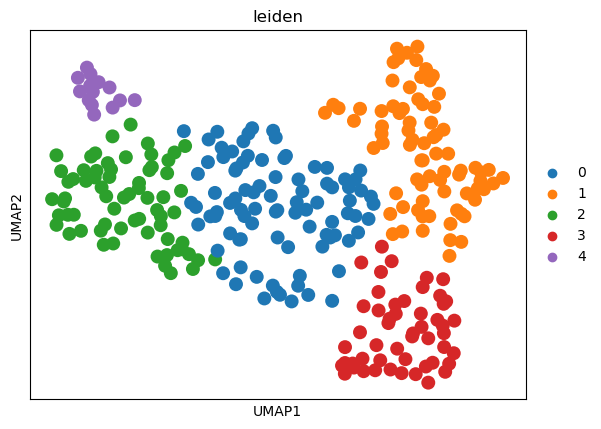

24092009


/data/biosoftware/miniconda3/miniconda3/envs/pytorch/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


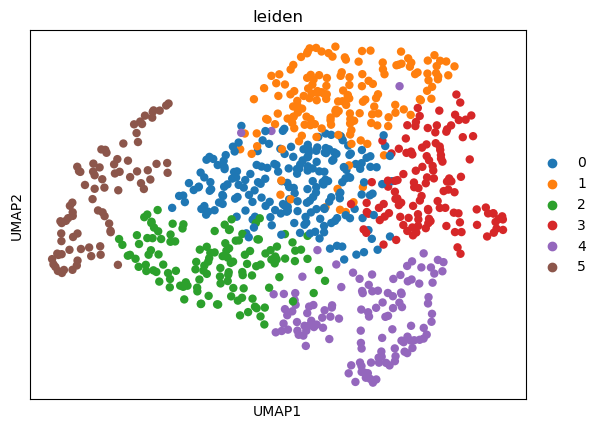

24092014


/data/biosoftware/miniconda3/miniconda3/envs/pytorch/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


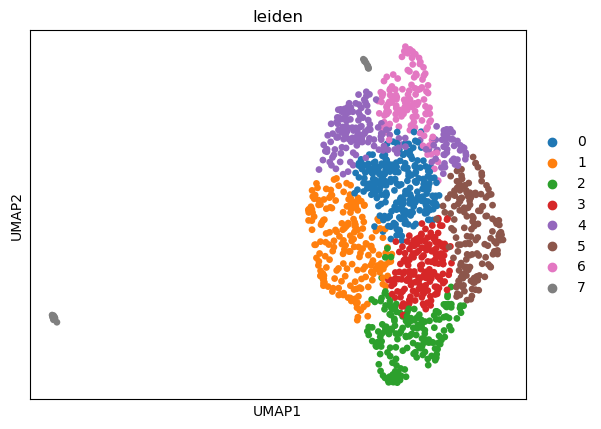

24092017


/data/biosoftware/miniconda3/miniconda3/envs/pytorch/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


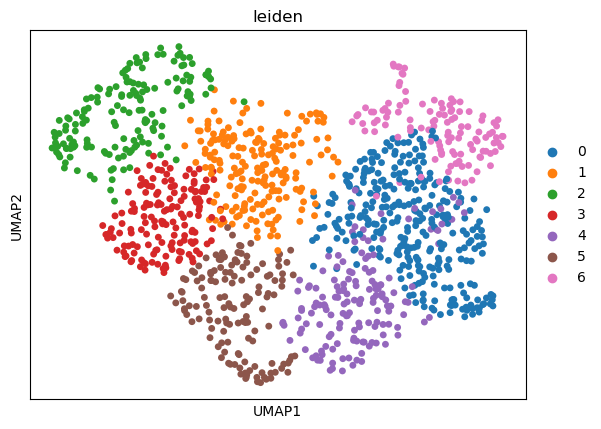

24092023


/data/biosoftware/miniconda3/miniconda3/envs/pytorch/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


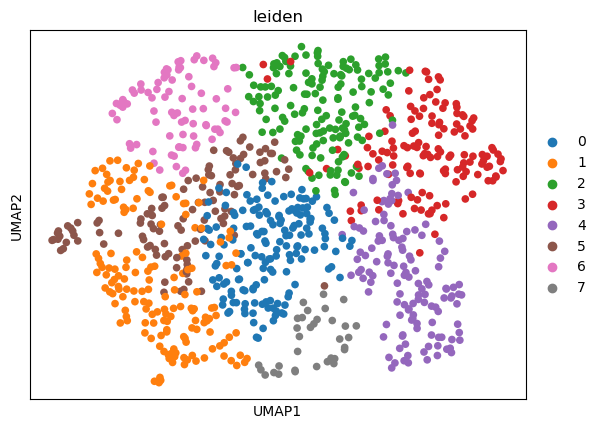

24092025


/data/biosoftware/miniconda3/miniconda3/envs/pytorch/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


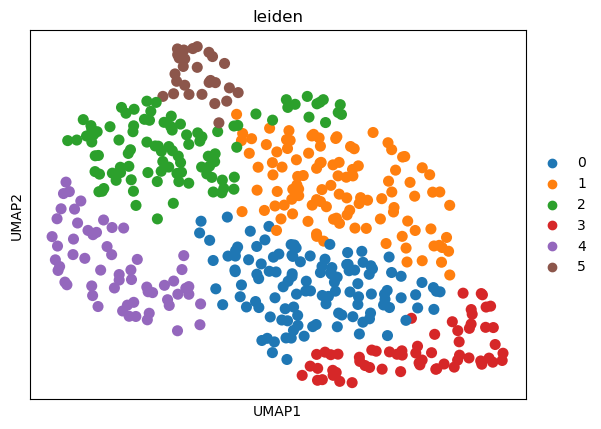

24092029


/data/biosoftware/miniconda3/miniconda3/envs/pytorch/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


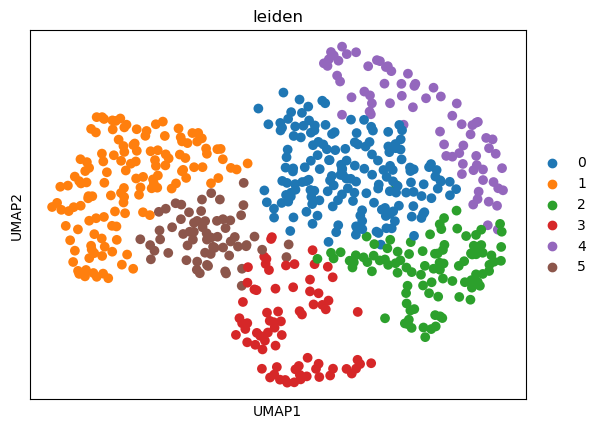

24092031


/data/biosoftware/miniconda3/miniconda3/envs/pytorch/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


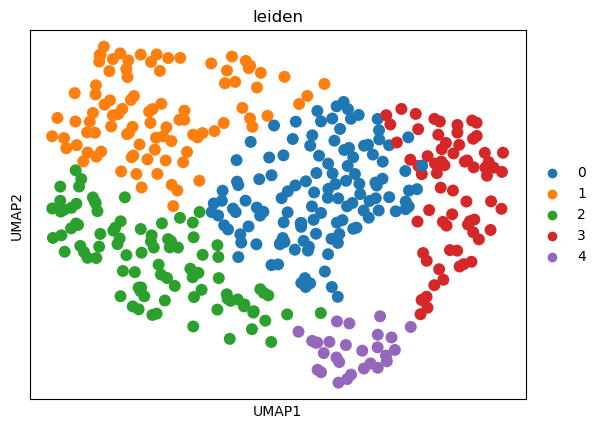

In [240]:
import pickle 
all_tomos = ['24092002',
 '24092013',
 '24092016',
 '24092020',
 '24092024',
 '24092026',
 '24092030',
 '24092009',
 '24092014',
 '24092017',
 '24092023',
 '24092025',
 '24092029',
 '24092031']
for name in all_tomos:
    print(name)
    with open(f"/home/feity/cryoem/temp/results/ribo_%s_gap1.pkl" % name, "rb") as f:
        res = pickle.load(f) 
    df = res["df"]
    graphs = res["graph"] 
    embeds = graphs.x
    embeds = embeds.cpu().numpy()
    subdf = df[df["label"] != ""]
    data_embed = embeds[ subdf.index.values, : ]
    obs = subdf.groupby("label_id")[["z", "x", "y", "w", "h", "ribo"]].mean().reset_index()
    all_ribos_embed = [] 
    for i in np.unique(subdf["label_id"]):
        t = subdf[subdf["label_id"] == i] 
        all_ribos_embed.append(embeds[t.index].mean(axis=0))
        if np.isnan(all_ribos_embed[-1]).any():
            print("nan in ribo embedding", i, t.index)
            all_ribos_embed[-1] = np.zeros(embeds.shape[1])
    all_ribos_embed = np.vstack(all_ribos_embed)
    ribo_adata = sc.AnnData(X=all_ribos_embed, obs=obs)
    sc.pp.pca(ribo_adata)
    sc.pp.neighbors(ribo_adata)
    sc.tl.umap(ribo_adata)
    sc.tl.leiden(ribo_adata, resolution=0.5)
    sc.pl.umap(ribo_adata, color=["leiden"])
    files = {"class1":"/data/transformer_project/transforemer_model/test_data/dxd20240920_classfication_final/run_data_job033_class1.star",
         "class2":"/data/transformer_project/transforemer_model/test_data/dxd20240920_classfication_final/run_data_job035_class2.star", 
         "class3":"/data/transformer_project/transforemer_model/test_data/dxd20240920_classfication_final/run_data_job037_class3.star",
         "class4":"/data/transformer_project/transforemer_model/test_data/dxd20240920_classfication_final/run_data_job039_class4.star"} 
    dfs = [] 
    for i in files:
        d = pd.read_csv(files[i], skiprows=43, sep="\\s+", header=None)
        d["need"] = d[0].apply(lambda x: name in x)
        d = d[d["need"]]
        d["class"] = i 
        dfs.append(d)
    dfs = pd.concat(dfs, axis=0)
    centers = dfs[[3, 2, 1]].values
    centers /= 4
    dfs.index = range(len(dfs))
    dfs["class"].value_counts()
    score, predict_center, ids = postprocess.getPredictionCenters(df, "ribo", image_size=1024)
    matches, match_dists, closest =   postprocess.match_and_find_closest(predict_center, centers)
    postprocess.calculate_metrics(matches, match_dists, score, threshold=15)
    matches = np.array(matches)
    ids_mapping = {i:j for i, j in enumerate(ids)}
    t = np.array(matches) 
    t = t[match_dists < 15]
    mapping = {} 
    for i in range(len(t)):
        # mapping[ids_mapping[t[i,1]]] = dfs.iloc[t[i,0]]["class"]
        mapping[ids_mapping[t[i,1]]] = t[i,0]
        
    ribo_adata.obs["class"] = ribo_adata.obs["label_id"].apply(lambda x: dfs.iloc[mapping[x]]["class"] if x in mapping else "unknown0")
    ribo_adata.obs["rlnAngleRot"] = ribo_adata.obs["label_id"].apply(lambda x: dfs.iloc[mapping[x]][4] if x in mapping else 0.0)
    ribo_adata.obs["rlnAngleTilt"] = ribo_adata.obs["label_id"].apply(lambda x: dfs.iloc[mapping[x]][5] if x in mapping else 0.0)
    ribo_adata.obs["rlnAnglePsi"] = ribo_adata.obs["label_id"].apply(lambda x: dfs.iloc[mapping[x]][6] if x in mapping else 0.0)
    ribo_adata.obs["class_num"] = ribo_adata.obs["class"].apply(lambda x: int(x[-1]))
    ribo_map = {
        0:0, 1:1, 2:1, 3:1, 4:2
    }
    ribo_adata.obs["class_num2"] = ribo_adata.obs["class_num"].apply(lambda x: ribo_map[x] if x in ribo_map else 0)
    # ribo_adata.obs.head()
    ribo_adata.write_h5ad(f"/home/feity/cryoem/temp/ribo_results/{name}.h5ad")

In [226]:

dataset = data.MrcDataset(
    # "/data/transformer_project/transforemer_model/test_data/dxd20240920_hsp60/24092018.pkl",
    # "/data/transformer_project/transforemer_model/test_data/dxd20240920_hsp60/24092002.pkl", 
    "/data/transformer_project/transforemer_model/train_data/training/newdata/TS_031_interpolate.pkl",
    # "/data/transformer_project/transforemer_model/train_data/training/newdata/24092002_ribo.pkl",
    norm="hist",
    reshape=800,
    map_class={"ribosome":0 },
    gap=1,
    length_for_average=3,
    transform=data.getConstantTransform(),
    add_classname=True,
    filtermin=0
)
# with open(f"/home/feity/cryoem/temp/results/ribo_%s_gap1.pkl" % "24092002", "rb") as f:
#     res = pickle.load(f)  
with open("/home/feity/cryoem/temp/ribo/TS031/ribo_near_ER_labels.pkl", "rb") as f:
    res = pickle.load(f)
df = res["df"]
graphs = res["graph"]
graphs

reading dataset: /data/transformer_project/transforemer_model/train_data/training/newdata/TS_031_interpolate.pkl
dataset map classes:  {'ribosome': 0}
dataset length: 283


Data(x=[36625, 262], edge_index=[2, 1104905], y=[36625], inter_edges=[1104905], box_masks=[36625], boxes=[36625, 4], item_id=[36625])

In [223]:
# embeds = []
# for i in graphs:
#     embeds.append(i.x[:, -256:])
# embeds = torch.concat(embeds, dim=0)
embeds = graphs.x
embeds = embeds.cpu().numpy()
subdf = df[df["label"] != ""]
subdf = subdf[subdf["label_id"] != -1]
data_embed = embeds[ subdf.index.values, : ]
embeds.shape

(36625, 262)

/data/biosoftware/miniconda3/miniconda3/envs/pytorch/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


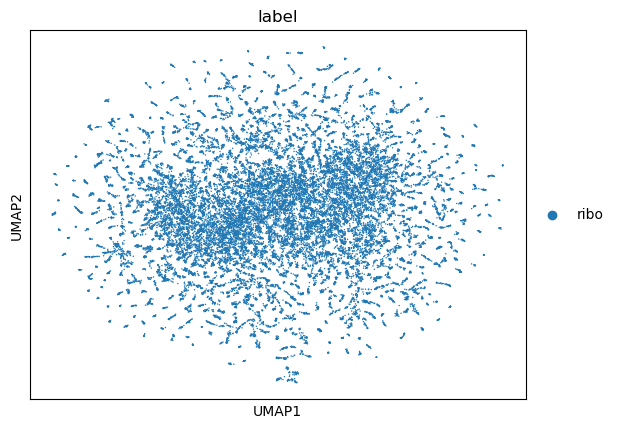

In [200]:
import scanpy as sc
adata = sc.AnnData(X=data_embed, obs=subdf)
sc.pp.pca(adata)
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=50)
sc.tl.umap(adata)
sc.pl.umap(adata, color=["label"])
# adata

In [224]:
obs = subdf.groupby("label_id")[["z", "x", "y", "w", "h", "ribo"]].mean().reset_index()
all_ribos_embed = [] 
for i in np.unique(subdf["label_id"]):
    t = subdf[subdf["label_id"] == i] 
    all_ribos_embed.append(embeds[t.index].mean(axis=0))
    if np.isnan(all_ribos_embed[-1]).any():
        print("nan in ribo embedding", i, t.index)
        all_ribos_embed[-1] = np.zeros(embeds.shape[1])
all_ribos_embed = np.vstack(all_ribos_embed)

In [227]:
obs["label"] = obs["label_id"].map(res["labels"])

/data/biosoftware/miniconda3/miniconda3/envs/pytorch/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


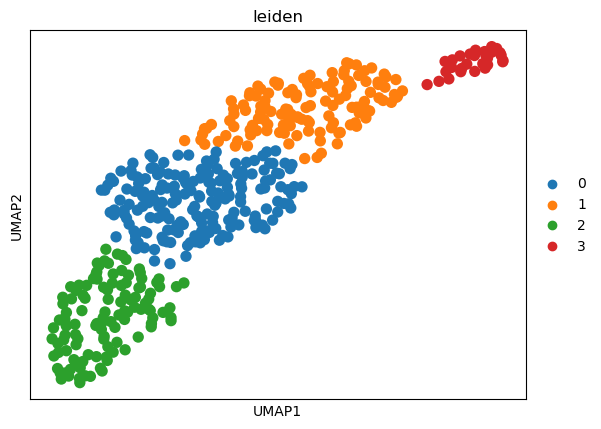

In [228]:
ribo_adata = sc.AnnData(X=all_ribos_embed, obs=obs)
sc.pp.pca(ribo_adata)
sc.pp.neighbors(ribo_adata)
sc.tl.umap(ribo_adata)
sc.tl.leiden(ribo_adata, resolution=0.5)
sc.pl.umap(ribo_adata, color=["leiden"])

/tmp/ipykernel_2458339/713678671.py:29: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  bboxes = torch.tensor(bboxes)*torch.tensor([img.shape[1], img.shape[2], img.shape[1], img.shape[2]])
/home/feity/cryoem/utils.py:74: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  annotated_tensor = torch.tensor(annotated_tensor, dtype=torch.uint8)


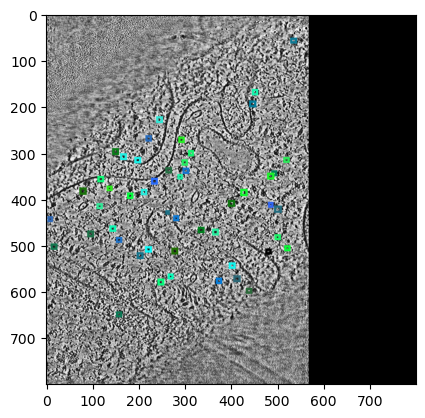

In [230]:
# take one slice and visualize
importlib.reload(utils)
take = 250
q = df["z"]
label3 = ribo_adata.obs[ribo_adata.obs["leiden"] == "0"]
ids = label3["label_id"].values
subdf = df
subdf = subdf[(subdf["label"] == "ribo")]
subdf = subdf[subdf["label_id"].isin(ids)]
subdf = subdf[subdf["z"] == take]
# subdf = subdf[subdf["nucleus"] > 0.3] 
# subdf = subdf[subdf["label"] == "nucleus"]

# img = retdict["images"][take]
img = dataset.__getitem__(pos=take)["pixel_values"]

# subdf2 = subdf.loc[need]
subdf2 = subdf

# subdf2 = df.loc[need2]

""" if use dbscan results """
subdf2 = subdf2[subdf2["label"] != -1]
# subdf2["label"] = subdf2["label"].astype("str")
# print(subdf2.head())

bboxes = subdf2[["x", "y", "w", "h"]].values
bboxes = utils.convertBoxes(torch.tensor(bboxes))
bboxes = torch.tensor(bboxes)*torch.tensor([img.shape[1], img.shape[2], img.shape[1], img.shape[2]])
# bboxes, img.shape
img[0] = img[1]
img[2] = img[1]
labels = {"bboxes": bboxes, "labels": [""] * len(bboxes)} 
utils.drawannotation(img, labels, font_size=10)

In [231]:
ribo_adata = ribo_adata[ribo_adata.obs["z"] > 110]
ribo_adata = ribo_adata[ribo_adata.obs["z"] < 400]
ribo_adata.write_h5ad("/home/feity/cryoem/temp/ribo/TS031/adata.h5ad")

In [173]:
files = {"class1":"/data/transformer_project/transforemer_model/test_data/dxd20240920_classfication_final/run_data_job033_class1.star",
         "class2":"/data/transformer_project/transforemer_model/test_data/dxd20240920_classfication_final/run_data_job035_class2.star", 
         "class3":"/data/transformer_project/transforemer_model/test_data/dxd20240920_classfication_final/run_data_job037_class3.star",
         "class4":"/data/transformer_project/transforemer_model/test_data/dxd20240920_classfication_final/run_data_job039_class4.star"} 
dfs = [] 
for i in files:
    d = pd.read_csv(files[i], skiprows=43, sep="\\s+", header=None)
    d["need"] = d[0].apply(lambda x: "24092002" in x)
    d = d[d["need"]]
    d["class"] = i 
    dfs.append(d)
dfs = pd.concat(dfs, axis=0)
centers = dfs[[3, 2, 1]].values
centers /= 4
dfs.index = range(len(dfs))
dfs["class"].value_counts()
# d1 = pd.read_csv(files["class1"], skiprows=42, sep="\\s+", header=None)
# d1["need"] = d1[6].apply(lambda x: "24092002" in x)
# d1[d1["need"]]

class
class4    378
class1    139
class3     61
class2     51
Name: count, dtype: int64

In [175]:
score, predict_center, ids = postprocess.getPredictionCenters(df, "ribo", image_size=1024)
# idx = np.argsort(-score)
# idx = idx[:400]
# score=score[idx[:500]] 
# score = score[idx]
# predict_center=predict_center[idx[:500]]
# predict_center = predict_center[idx]
# ids = ids[idx[:500]]
# ids = ids[idx]
# zmin = df["z"].min()
# zmax = df["z"].max()
# centers = dfs[["z", "y", "x"]].values
# centers = centers[centers[:, 0] >= zmin]
# centers = centers[centers[:, 0] <= zmax]
matches, match_dists, closest =   postprocess.match_and_find_closest(predict_center, centers)
postprocess.calculate_metrics(matches, match_dists, score, threshold=15)#, len(idx)

{'auroc': 0.5261499684940139,
 'aupr': 0.9940487731526266,
 'aupr2': 0.9940717750677165,
 'cnts': 529}

In [176]:
matches = np.array(matches)
ids_mapping = {i:j for i, j in enumerate(ids)}
t = np.array(matches) 
t = t[match_dists < 15]
mapping = {} 
for i in range(len(t)):
    mapping[ids_mapping[t[i,1]]] = dfs.iloc[t[i,0]]["class"]
# t = dict(t[:, [1, 0]])
# for i in t:
#     t[i] = ids_mapping[t[i]]

In [177]:
ribo_adata.obs["class"] = ribo_adata.obs["label_id"].apply(lambda x: mapping[x] if x in mapping else "unknown0")
ribo_adata.obs["class_num"] = ribo_adata.obs["class"].apply(lambda x: int(x[-1]))
ribo_map = {
    0:0, 1:1, 2:2, 3:1, 4:1
}
ribo_adata.obs["class_num2"] = ribo_adata.obs["class_num"].apply(lambda x: ribo_map[x] if x in ribo_map else 0)
ribo_adata.obs.head()
# ribo_adata.obs.head()

,label_id,z,x,y,w,h,ribo,leiden,class,class_num,class_num2
0,7,76.5,0.060830,0.153489,0.022413,0.022542,0.655149,1,class4,4,1
1,8,81.0,0.119568,0.313783,0.023631,0.023405,0.426669,2,class4,4,1
2,10,96.0,0.141181,0.010356,0.025341,0.023647,0.596547,5,class1,1,1
3,11,82.0,0.111454,0.287148,0.023376,0.023553,0.458343,2,class4,4,1
4,12,95.0,0.059896,0.279124,0.024095,0.024712,0.461918,1,class3,3,1


In [214]:
ribo_adata

AnnData object with n_obs × n_vars = 452 × 262
    obs: 'label_id', 'z', 'x', 'y', 'w', 'h', 'ribo', 'leiden'
    uns: 'pca', 'neighbors', 'umap', 'leiden', 'leiden_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

In [178]:
ribo_adata.write_h5ad("/home/feity/cryoem/temp/ribo/TS031/old_24092002.h5ad")

In [237]:
import anndata
import os 
t = {}
for i in os.listdir("/home/feity/cryoem/temp/ribo_results/"):
    if i.endswith(".h5ad") and i.startswith("2409"):
        name = i.split(".h5ad")[0]
        t[name] = sc.read_h5ad(os.path.join("/home/feity/cryoem/temp/ribo_results/", i))
# t = {"a1":sc.read_h5ad("/home/feity/cryoem/temp/ribo_results/24092002.h5ad"), 
#      "a2":sc.read_h5ad("/home/feity/cryoem/temp/ribo_results/24092020.h5ad"),
#      "a3":sc.read_h5ad("/home/feity/cryoem/temp/ribo_results/24092026.h5ad")}
ribo_adata = anndata.concat(t, label="tomogram")
ribo_adata = ribo_adata[ribo_adata.obs["class"] != "unknown0"]

/data/biosoftware/miniconda3/miniconda3/envs/pytorch/lib/python3.12/site-packages/anndata/_core/anndata.py:1791: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


/data/biosoftware/miniconda3/miniconda3/envs/pytorch/lib/python3.12/site-packages/scanpy/preprocessing/_pca/__init__.py:385: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = X_pca
/data/biosoftware/miniconda3/miniconda3/envs/pytorch/lib/python3.12/site-packages/anndata/_core/anndata.py:1791: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/data/biosoftware/miniconda3/miniconda3/envs/pytorch/lib/python3.12/site-packages/anndata/_core/anndata.py:1791: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


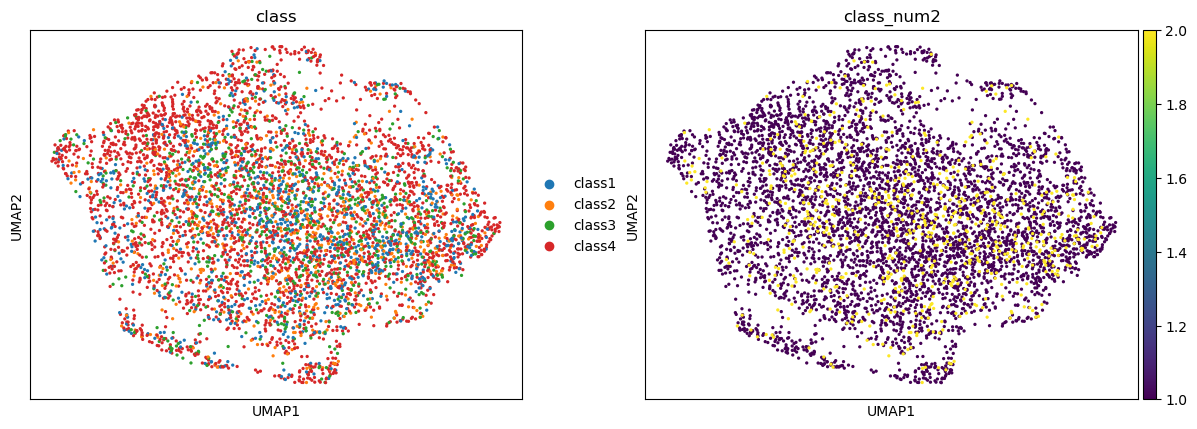

/data/biosoftware/miniconda3/miniconda3/envs/pytorch/lib/python3.12/site-packages/scanpy/preprocessing/_pca/__init__.py:385: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = X_pca
/data/biosoftware/miniconda3/miniconda3/envs/pytorch/lib/python3.12/site-packages/anndata/_core/anndata.py:1791: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/data/biosoftware/miniconda3/miniconda3/envs/pytorch/lib/python3.12/site-packages/anndata/_core/anndata.py:1791: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


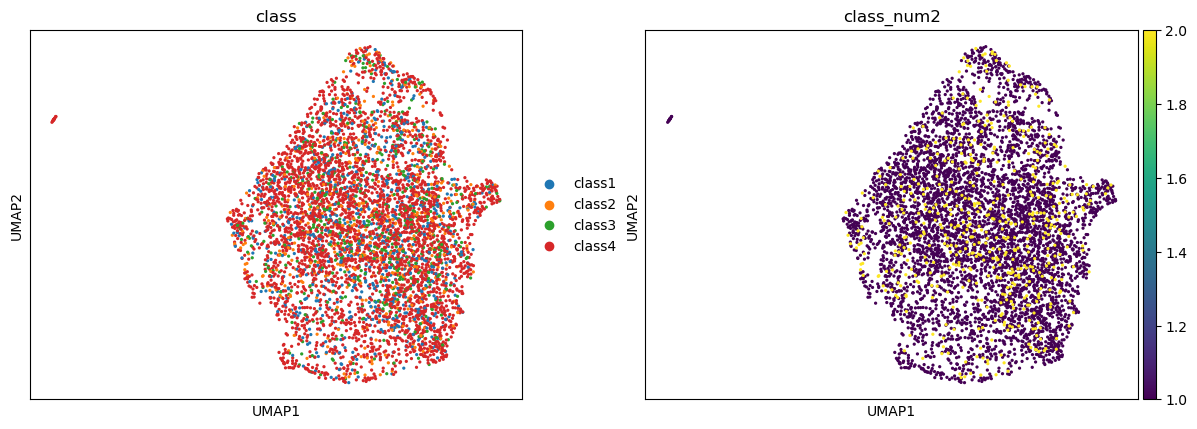

In [194]:
ribo_adata_fold1 = ribo_adata[ribo_adata.obs["tomogram"].isin(["24092002", "24092013", "24092016", "24092020", "24092024", "24092026", "24092030"])] 
ribo_adata_fold2 = ribo_adata[ribo_adata.obs["tomogram"].isin(["24092009", "24092014", "24092017", "24092023", "24092025", "24092029", "24092031"])]
sc.pp.pca(ribo_adata_fold1)
sc.pp.neighbors(ribo_adata_fold1)
sc.tl.umap(ribo_adata_fold1)
sc.tl.leiden(ribo_adata_fold1, resolution=0.5)
sc.pl.umap(ribo_adata_fold1, color=["class", "class_num2"])
sc.pp.pca(ribo_adata_fold2)
sc.pp.neighbors(ribo_adata_fold2)
sc.tl.umap(ribo_adata_fold2)
sc.tl.leiden(ribo_adata_fold2, resolution=0.5)
sc.pl.umap(ribo_adata_fold2, color=["class", "class_num2"])
ribo_adata_fold1.write_h5ad("/home/feity/cryoem/temp/ribo_results/fold1.h5ad")
ribo_adata_fold2.write_h5ad("z/home/feity/cryoem/temp/ribo_results/fold2.h5ad")

In [241]:
ribo_adata.obs["class"].value_counts()

class
class4      286
class1       55
unknown0     26
class3       25
class2       12
Name: count, dtype: int64

In [206]:
np.sin(np.deg2rad(90))

1.0

/data/biosoftware/miniconda3/miniconda3/envs/pytorch/lib/python3.12/site-packages/scanpy/preprocessing/_pca/__init__.py:385: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = X_pca
/data/biosoftware/miniconda3/miniconda3/envs/pytorch/lib/python3.12/site-packages/anndata/_core/anndata.py:1791: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/data/biosoftware/miniconda3/miniconda3/envs/pytorch/lib/python3.12/site-packages/anndata/_core/anndata.py:1791: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


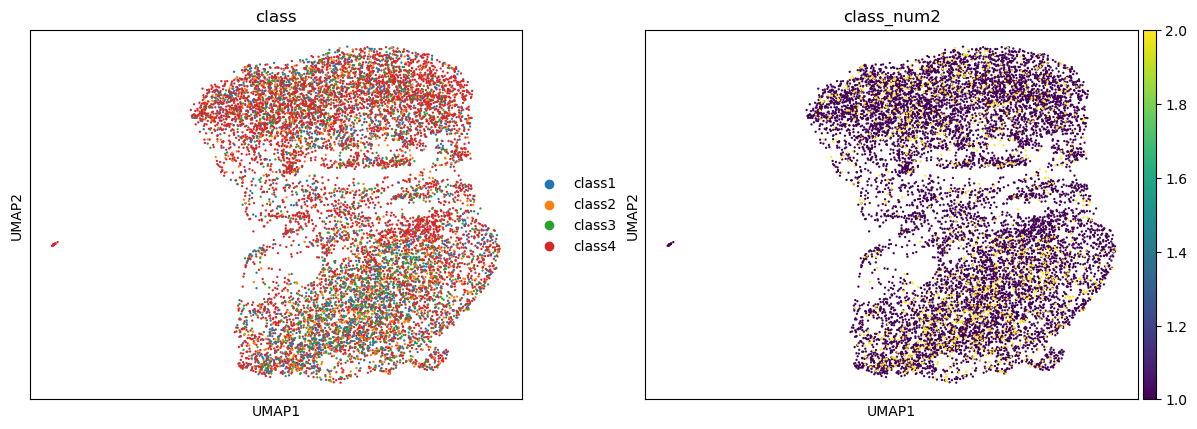

In [188]:
sc.pp.pca(ribo_adata)
sc.pp.neighbors(ribo_adata)
sc.tl.umap(ribo_adata)
sc.tl.leiden(ribo_adata, resolution=0.5)
sc.pl.umap(ribo_adata, color=["class", "class_num2"])

In [189]:
ribo_adata.write_h5ad(f"/home/feity/cryoem/temp/ribo_results/all_ribo_1019.h5ad")

In [234]:
ribo_adata.obs["label"].value_counts()  

label
0    249
1    202
Name: count, dtype: int64

In [235]:
ribo_adata.obs["label"] += 1

/tmp/ipykernel_2458339/1198354859.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  ribo_adata.obs["label"] += 1


In [2]:
import scanpy as sc
ribo_adata = sc.read_h5ad(f"/home/feity/cryoem/temp/ribo_results/24092002.h5ad")
ribo_adata   

AnnData object with n_obs × n_vars = 532 × 262
    obs: 'label_id', 'z', 'x', 'y', 'w', 'h', 'ribo', 'leiden', 'class', 'rlnAngleRot', 'rlnAngleTilt', 'rlnAnglePsi', 'class_num', 'class_num2'
    uns: 'leiden', 'leiden_colors', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [ ]:
all_tomos = ['24092002',
 '24092013',
 '24092016',
 '24092020',
 '24092024',
 '24092026',
 '24092030',
 '24092009',
 '24092014',
 '24092017',
 '24092023',
 '24092025',
 '24092029',
 '24092031']

all_res_auroc = {}
all_res_acc = {} 
for name in all_tomos:
    print(name)
    ribo_adata = sc.read_h5ad(f"/home/feity/cryoem/temp/ribo_results/%s.h5ad"%name)

    X = ribo_adata.X.astype(np.float32)
    # Y: 4 possible classes (0,1,2,3)
    # Y = ribo_adata.obs["leiden"].astype(int).values
    # Y  = ribo_adata.obs["class_num"].astype(int).values
    # Y  = ribo_adata.obs["label"].astype(int).values
    Y = ribo_adata.obs["class_num2"].astype(int).values
    num_classes = 2
    X = X[Y!=0]
    Y= Y[Y!=0]-1
    a, b = np.unique(Y, return_counts=True)
    weights = np.zeros(num_classes)
    for i, c in zip(a, b):
        weights[i] = np.sum(b) / c

    # Encode labels if not already integers
    # encoder = LabelEncoder()
    # Y = encoder.fit_transform(Y)

    # ===== Train-test split =====
    X_train, X_test, y_train, y_test = train_test_split(
        X, Y, test_size=0.2, random_state=42, stratify=Y
    )

    # Convert to PyTorch tensors
    X_train_t = torch.tensor(X_train, dtype=torch.float32)
    y_train_t = torch.tensor(y_train, dtype=torch.long)
    X_test_t = torch.tensor(X_test, dtype=torch.float32)
    y_test_t = torch.tensor(y_test, dtype=torch.long)

    # ===== Simple Fully Connected Network =====
    class SimpleFC(nn.Module):
        def __init__(self, input_size, hidden_size, num_classes):
            super(SimpleFC, self).__init__()
            
            self.net = nn.Sequential(
                nn.Linear(input_size, hidden_size),
                nn.ReLU(),
                # nn.Dropout(0.2),
                nn.Linear(hidden_size, hidden_size),
                nn.ReLU(),
                # nn.Dropout(0.2),
                nn.Linear(hidden_size, num_classes)
            )
        def forward(self, x):
            out = self.net(x)
            return out

    # Instantiate model
    model = SimpleFC(input_size=262, hidden_size=64, num_classes=num_classes)
    # Loss and optimizer
    criterion = nn.CrossEntropyLoss(weight=torch.tensor(weights).float())
    # criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    # ===== Training loop =====
    max_acc = 0.0
    epochs = 2000
    for epoch in range(epochs):
        model.train()
        outputs = model(X_train_t)
        # print(outputs.shape, y_train_t.shape)
        loss = criterion(outputs, y_train_t)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if (epoch+1) % 5 == 0:
            model.eval()
            with torch.no_grad():
                preds = torch.argmax(model(X_test_t), dim=1)
                acc = accuracy_score(y_test_t.numpy(), preds.numpy())
            print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}, Test Acc: {acc:.4f}")
            if acc > max_acc:
                max_acc = acc
                torch.save(model.state_dict(), "/home/feity/cryoem/temp/ribo_results/ribo_classifier_24092002.pth")
                print(f"New best model saved with accuracy: {max_acc:.4f}")

    # ===== Final evaluation =====
    model.load_state_dict(torch.load("/home/feity/cryoem/temp/ribo_results/ribo_classifier_24092002.pth"))
    model.eval()

    with torch.no_grad():
        preds = torch.argmax(model(X_train_t), dim=1)
        final_acc = accuracy_score(y_train_t.numpy(), preds.numpy())
    print(f"Final Train Accuracy: {final_acc:.4f}")

    with torch.no_grad():
        preds = torch.argmax(model(X_test_t), dim=1)
        final_acc = accuracy_score(y_test_t.numpy(), preds.numpy())
        
    from sklearn.metrics import roc_auc_score, precision_recall_curve, auc, f1_score

    # y_proba = torch.softmax(torch.tensor(model(X_test_t).detach().numpy()), dim=1)[:,1].numpy()
    auroc = roc_auc_score(y_test_t.numpy(), preds.numpy())
    precision, recall, _ = precision_recall_curve(y_test_t.numpy(), preds.numpy())
    aupr = auc(recall, precision)
    f1 = f1_score(y_test_t.numpy(), preds.numpy())
    print(f"AUROC: {auroc:.4f}, AUPR: {aupr:.4f}, F1-score: {f1:.4f}")
    print(f"Final Test Accuracy: {final_acc:.4f}")
    print(f"best Test Accuracy: {max_acc:.4f}")
    all_res_auroc[name] = auroc
    all_res_acc[name] = max_acc

              precision    recall  f1-score   support

      Class0       0.19      0.14      0.16        36
      Class1       0.38      0.44      0.40        39
      Class2       0.27      0.23      0.25        31
      Class3       0.46      0.53      0.50        58

    accuracy                           0.37       164
   macro avg       0.33      0.33      0.33       164
weighted avg       0.35      0.37      0.35       164

Accuracy: 0.3659


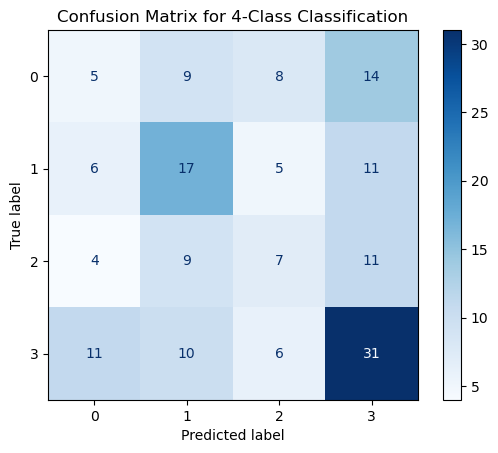

In [248]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

y_true = y_test_t.numpy() 
y_pred = preds.numpy()
accuracy = accuracy_score(y_true, y_pred)

print(classification_report(
    y_true,
    y_pred,
    target_names=["Class"+str(i) for i in range(num_classes)]
))
print(f"Accuracy: {accuracy:.4f}")

# 2. Confusion matrix
cm = confusion_matrix(y_true, y_pred)

# 3. Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[i for i in range(num_classes)])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for 4-Class Classification")
plt.show()

In [ ]:
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc, f1_score

# Compute AUROC, AUPR, F1 for test set
# y_true and y_pred already defined above
# For AUROC/AUPR, need probability scores for positive class
if num_classes == 2:
    # For binary, get probability for class 1
    y_proba = torch.softmax(torch.tensor(model(X_test_t).detach().numpy()), dim=1)[:,1].numpy()
    auroc = roc_auc_score(y_true, y_proba)
    precision, recall, _ = precision_recall_curve(y_true, y_proba)
    aupr = auc(recall, precision)
    f1 = f1_score(y_true, y_pred)
    print(f"Test AUROC: {auroc:.4f}")
    print(f"Test AUPR: {aupr:.4f}")
    print(f"Test F1: {f1:.4f}")
else:
    # For multiclass, average='macro'
    y_proba = torch.softmax(torch.tensor(model(X_test_t).detach().numpy()), dim=1).numpy()
    auroc = roc_auc_score(y_true, y_proba, multi_class='ovr', average='macro')
    # AUPR for multiclass: compute for each class and average
    aupr_list = []
    for i in range(num_classes):
        precision, recall, _ = precision_recall_curve((y_true==i).astype(int), y_proba[:,i])
        aupr_list.append(auc(recall, precision))
    aupr = np.mean(aupr_list)
    f1 = f1_score(y_true, y_pred, average='macro')
    print(f"Test AUROC (macro): {auroc:.4f}")
    print(f"Test AUPR (macro): {aupr:.4f}")
    print(f"Test F1 (macro): {f1:.4f}")

In [19]:
# a = np.unique(df["label_id"]) 
d = ribo_adata.obs
d = d[d["class"] != "unknown0"]
a = list(d["label_id"])
mapdict = dict(zip(d["label_id"], d["class"]))
df["class"] = df["label_id"].apply(lambda x: mapdict.get(x, "unknown0"))
df["class_value"] = df["class"].apply(lambda x: int(x[-1]))
df["class_value2"] = df["class_value"].apply(lambda x: ribo_map[x] if x in ribo_map else 0)
train_data, test_data = train_test_split(a, test_size=0.2, random_state=42)

In [20]:
df["train_mask"] = df["label_id"].apply(lambda x: True if x in train_data and x!=-1 else False)
df["test_mask"] = df["label_id"].apply(lambda x: True if x in test_data and x!=-1 else False)

In [21]:
torch.min(label[train_mask])

NameError: name 'label' is not defined

In [37]:
import modules
from torch_geometric.utils import subgraph

model_fineTune = modules.GCN(256, 262, 2) 

# make sure the architecture is the same as the pre-trained model, otherwise pop out incompatible keys
model_fineTune.load_state_dict(model.gnn.state_dict())

train_mask = torch.tensor(df["train_mask"].values)
test_mask = torch.tensor(df["test_mask"].values)
label = torch.tensor(df["class_value2"].values) - 1 
require_nodes = torch.where(train_mask | test_mask)[0]
sub_edge_index, _ = subgraph(require_nodes, graph.edge_index, relabel_nodes=True) 
# graph.x = graph.x[require_nodes]
label = label[require_nodes]
train_mask = train_mask[require_nodes]
test_mask = test_mask[require_nodes]

model_fineTune = model_fineTune.train()
optimizer = torch.optim.Adam(model_fineTune.parameters(), lr=0.001) 
criterion = nn.CrossEntropyLoss()
epochs = 500

In [38]:
graph.x.shape

torch.Size([17625, 262])

In [ ]:
from tqdm import tqdm
model_fineTune = model_fineTune.cuda(0)

for epoch in tqdm(range(epochs)):
    model_fineTune.train()
    optimizer.zero_grad()
    out = model_fineTune(graph.x.cuda(0), sub_edge_index.cuda(0))
    loss = criterion(out["predict"][train_mask], label[train_mask].cuda(0))
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 10 == 0:
        model_fineTune.eval()
        _, pred = out["predict"].max(dim=1)
        correct = int(pred[test_mask].eq(label[test_mask].cuda(0)).sum().item())
        acc = correct / int(test_mask.sum())
        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}, Test Acc: {acc:.4f}")